In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import os

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["GRB_LICENSE_FILE"] = "/usr0/home/naveenr/gurobi.lic"
os.environ['MKL_THREADING_LAYER'] = "GNU"

In [6]:
from concept_abstraction.training import *
from concept_abstraction.selection import *
from concept_abstraction.concept_bank import *
from concept_abstraction.env_utils import *
from concept_abstraction.environments import *
from concept_abstraction.utils import *
from concept_abstraction.environments import ConceptEnv
import sys 
import argparse
import secrets
import numpy as np 
import random 
import os
from stable_baselines3 import PPO
import pickle
import resource

In [7]:
is_jupyter = 'ipykernel' in sys.modules
is_main = __name__ == "__main__"

In [8]:
if is_main:
    if is_jupyter: 
        # Basics 
        seed        = 42
        environment_string = "cart_pole"
        gold_timesteps = 4_000_000
        training_timesteps = 1_000_000
        num_concepts_selected = 24
        selection_function = "q_value"
        # Experiment #1 & #2
        run_basic = False
        run_iterative = False 
        run_two_stage = False  
        run_imperfect=True
        run_intervention=True
        # Experiment #3
        cbm_accuracy_by_concept = [0.96542056, 0.96542056, 0.9682243 , 0.9682243 , 0.82429907,
       0.82336449, 0.79906542, 0.8       , 0.93084112, 0.92336449,
       0.94859813, 0.94859813, 0.80747664, 0.80934579, 0.82616822,
       0.82803738]
        intervention_probability = 0
        intervention_accuracy_by_concept = None 
        cbm_std_by_concept = None 
        target_abstraction = 0.05
        reward_error = 0
        # Experiment #4
        concept_source = "human_selected_binary"
        # Experiment #5
        assess_completeness=False
        # Experiment #6
        num_iterations = 0
        selections_per_round = 0
        initial_concepts = 0
        out_folder = "llm"
    else:
        parser = argparse.ArgumentParser()
        parser.add_argument('--seed', help='Random Seed', type=int, default=42)
        parser.add_argument('--environment_string', help='Which environment to create', type=str, default="tree")
        parser.add_argument('--training_timesteps', help='Number of training timesteps', type=int, default=10000)
        parser.add_argument('--gold_timesteps', help='Number of training timesteps without concepts', type=int, default=10000)
        parser.add_argument('--num_concepts_selected', help='Number of concepts selected by greedy or random',type=int, default=0)
        parser.add_argument('--selection_function', help='When selecting, use q_value, policy, or transition?', type=str, default="policy")
        parser.add_argument('--cbm_accuracy_by_concept', help="What is the accuracy of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--intervention_accuracy_by_concept', help="What is the accuracy of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--cbm_std_by_concept', help="What is the error of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--run_two_stage', help='Run the two stage?', action='store_true')
        parser.add_argument('--run_iterative', help='Run the iterative?', action='store_true')
        parser.add_argument('--run_intervention', help='Run the intervention?', action='store_true')
        parser.add_argument('--run_basic', help='Run the basic comparisons?', action='store_true')
        parser.add_argument('--run_imperfect', help='Run the imperfect comparisons?', action='store_true')
        parser.add_argument('--intervention_probability', help='Value for the target abstraction with human performance', type=float, default=0.05)
        parser.add_argument('--target_abstraction', help='Value for the target abstraction with human performance', type=float, default=0.05)
        parser.add_argument('--reward_error', help="How much to perturb the reward by?", type=float, default=0)
        parser.add_argument('--concept_source', help='When selecting, use q_value, policy, or transition?', type=str, default="human_selected")
        parser.add_argument('--assess_completeness', help='Compare to the concept completeness algorithm?', action='store_true')
        parser.add_argument('--num_iterations', help='Number of iterations for iterative algorithms',type=int, default=0)
        parser.add_argument('--selections_per_round', help='Concepts to select per round',type=int, default=0)
        parser.add_argument('--initial_concepts', help='Number of starting/initial concepts',type=int, default=0)
        parser.add_argument('--out_folder', help='Which folder', type=str, default="exploration")

        args = parser.parse_args()

        seed = args.seed
        environment_string = args.environment_string
        training_timesteps = args.training_timesteps 
        gold_timesteps = args.gold_timesteps
        num_concepts_selected = args.num_concepts_selected
        selection_function = args.selection_function
        cbm_accuracy_by_concept = args.cbm_accuracy_by_concept
        cbm_std_by_concept = args.cbm_std_by_concept
        run_basic = args.run_basic
        run_iterative = args.run_iterative
        run_two_stage = args.run_two_stage
        run_imperfect = args.run_imperfect
        run_intervention = args.run_intervention
        intervention_probability = args.intervention_probability
        intervention_accuracy_by_concept = args.intervention_accuracy_by_concept
        target_abstraction = args.target_abstraction
        reward_error = args.reward_error
        concept_source = args.concept_source
        assess_completeness = args.assess_completeness
        num_iterations = args.num_iterations 
        selections_per_round = args.selections_per_round
        initial_concepts = args.initial_concepts
        out_folder = args.out_folder

    save_name = secrets.token_hex(4)  

In [9]:
if is_main:
        results = {}
        results['parameters'] = {'seed'      : seed,
                'environment_string'    : environment_string, 
                'training_timesteps': training_timesteps, 
                'gold_timesteps': gold_timesteps,
                'selection_function': selection_function,
                'num_concepts_selected': num_concepts_selected,
                'cbm_accuracy_by_concept': cbm_accuracy_by_concept,
                'cbm_std_by_concept': cbm_std_by_concept,
                'intervention_probability': intervention_probability,
                'intervention_accuracy_by_concept': intervention_accuracy_by_concept,
                'target_abstraction': target_abstraction,
                'reward_error': reward_error, 
                'concept_source': concept_source,
                'assess_completeness': assess_completeness,
                'num_iterations': num_iterations,
                'selections_per_round': selections_per_round, 
                'initial_concepts': initial_concepts,
                'run_basic': run_basic,
                'run_iterative': run_iterative, 
                'run_two_stage': run_two_stage, 
                'run_intervention': run_intervention,
                'run_imperfect': run_imperfect, 
        }
        print("Parameters {}".format(results['parameters']))

Parameters {'seed': 42, 'environment_string': 'cart_pole', 'training_timesteps': 1000000, 'gold_timesteps': 4000000, 'selection_function': 'q_value', 'num_concepts_selected': 24, 'cbm_accuracy_by_concept': [0.96542056, 0.96542056, 0.9682243, 0.9682243, 0.82429907, 0.82336449, 0.79906542, 0.8, 0.93084112, 0.92336449, 0.94859813, 0.94859813, 0.80747664, 0.80934579, 0.82616822, 0.82803738], 'cbm_std_by_concept': None, 'intervention_probability': 0, 'intervention_accuracy_by_concept': None, 'target_abstraction': 0.05, 'reward_error': 0, 'concept_source': 'human_selected_binary', 'assess_completeness': False, 'num_iterations': 0, 'selections_per_round': 0, 'initial_concepts': 0, 'run_basic': False, 'run_iterative': False, 'run_two_stage': False, 'run_intervention': True, 'run_imperfect': True}


In [10]:
if is_main:
    np.random.seed(seed)
    random.seed(seed)

### Basic Setup

In [11]:
if is_main:
    concept_list = get_concepts(environment_string,concept_source,seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))
    ground_truth_env, ground_truth_gym_env, additional_info = get_environment(environment_string, None, seed)   

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [12]:
gold_timesteps = 1_000_000
gold_timesteps

1000000

In [11]:
# if is_main:
#     model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,gold_timesteps,seed)
    
#     # if os.path.exists(model_name):
#     #     print("Model exists!")
#     #     groundtruth_model = PPO.load(model_name)
#     #     additional_info['subset_concepts'] = get_concepts(environment_string,"human_selected",seed)
#     # else:
#     groundtruth_model = train_ppo_model(ground_truth_env,environment_string,total_timesteps=gold_timesteps,policy="CnnPolicy")
#     #     groundtruth_model.save(model_name)
#     # groundtruth_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,groundtruth_model,seed)
#     # results['ground_truth'] = {'reward':groundtruth_reward}
#     # print("Basic:",results['ground_truth']['reward'])

wandb: Currently logged in as: naveenr (naveenr-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Unexpected exception formatting exception. Falling back to standard exception
Error in callback <bound method AutoreloadMagics.post_execute_hook of <IPython.extensions.autoreload.AutoreloadMagics object at 0x7fadc017ff10>> (for post_execute), with arguments args (),kwargs {}:
Unexpected exception formatting exception. Falling back to standard exception


fatal   : Memory allocation failure
fatal   : Memory allocation failure
Traceback (most recent call last):
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3577, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_837053/2741261490.py", line 9, in <module>
  File "/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/training.py", line 213, in train_ppo_model
    model.learn(total_timesteps=total_timesteps, callback=WandbLoggingCallback())
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/stable_baselines3/ppo/ppo.py", line 311, in learn
    return super().learn(
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/stable_baselines3/common/on_policy_algorithm.py", line 337, in learn
    self.train()
  File "/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/stable_baselines3/ppo/ppo.py", line 278, in tr

### Basic Comparison

In [13]:
if is_main:    
    model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}_source={}.pkl".format(environment_string,gold_timesteps,seed,selection_function,concept_source)
    results['basic_comparison'] = {}
    if os.path.exists(model_name):
        q_estimates = pickle.load(open(model_name,"rb"))
    else:
        if selection_function == "q_value":
            if environment_string == "glucose":
                q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list,total_timesteps=20_000)
            else:
                q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)
        elif selection_function == "policy":
            q_estimates = rollout_pi_estimates(groundtruth_model,ground_truth_gym_env,concept_list)
        pickle.dump(q_estimates,open(model_name,"wb"))

In [16]:
if is_main and run_basic:
    # Train a random policy
    if environment_string == "mimic":
        model = RandomAgent(GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])))
    else:
        model = RandomAgent(ground_truth_gym_env)
    random_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,model,seed)
    results['basic_comparison']['random'] = {'reward':random_reward}
    print("Random:",results['basic_comparison']['random']['reward'])

In [20]:
if is_main and run_basic:
    # Train a random selector
    subset_concept, random_idx = random_selection(concept_list,num_concepts_selected)
    subset_concept = [concept_list[i] for i in random_idx]
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)    
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_random".format(environment_string))
    random_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['random_selection'] = {'reward':random_selection_reward, 'concepts': random_idx}
    print("Random Selection:",results['basic_comparison']['random_selection']['reward'])

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,▃▁▁▁▁▁▁▂▂▂▂▃▃▁▁▃▂▂▂▁▄▁▁█▃▂▂▁▁▃▂▂▃▂▂▂▁▂▂▂
avg_norm_reward,▁▁▁▁▁▁▁▁▁▁▂▁▃▁▄▅▅▅██▇▅█▆▄▆▃█▇▇██████████
clip_fraction,▁▁▁▁▁▁▁▁▁▁▁▄▁▁▂▁▁▁▁▁█▃▁▁▁▄▃▁▃▂▁▂▂▂▂▂▃▁▄▄
ema_norm_reward,▁▁▁▁▁▁▁▁▁▃▄▅▆▅▅▅▅▆▇█▅▄▆▄▆▅▅▆▇▇▇█████████
entropy_loss,▁▂▂▂▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▅▄▇▇▇▇██
episode_length,▁▁▁▁▃▂▄▅▃▅▃▇▆▆█▆▆▆▄▇█▅▄▄▄▇▅▅▅▄███▆██████
episode_reward,▁▁▁▁▁▂▃▅▂█▆▆▃██▄▅▇▄▄█▄▃▅▅▅██████████████
explained_variance,████████████████████████████▆▆▆▅▆▄▂▃▅▅▄▁
value_loss,▇▆▆▅▅▄▃▄▄▄▂▂▅▇▇▆▆█▇▇▆▆▄▃▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁
approx_kl,0.0023
avg_norm_reward,500


Random Selection: 494.8453608247423


In [18]:
if is_main and run_basic:
    # Train a greedy selector
    subset_concept, greedy_idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_greedy".format(environment_string))
    greedy_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['greedy'] = {'concepts': greedy_idx, 'reward':greedy_selection_reward}
    print("Greedy:",results['basic_comparison']['greedy']['reward'])


In [19]:
if is_main and run_basic:
    subset_concept, lp_idx = lp_based_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_lp".format(environment_string))
    lp_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['lp'] = {'concepts': lp_idx, 'reward': lp_selection_reward}
    print("LP Selection:",results['basic_comparison']['lp']['reward'])

In [20]:
if is_main and run_basic:
    subset_concept, multiple_idx = multiple_lp_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_multiple".format(environment_string))
    multiple_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['multiple'] = {'concepts': multiple_idx, 'reward': multiple_selection_reward}
    print("Multiple Selection:",results['basic_comparison']['multiple']['reward'])

### Imperfect Concept Predictors

In [22]:
if is_main and run_imperfect:
    results['inaccurate_comparison'] = {}


In [25]:
if is_main and run_imperfect:
    greedy_inaccurate_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed) for (func,acc) in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        subset_concept, greedy_idx = concept_list, list(range(len(concept_list))) # greedy_selection(modified_concept_predictors,num_concepts_selected,selection_function,q_estimates,concept_source)
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_error_greedy".format(environment_string))
        greedy_inaccurate_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': greedy_idx
        }

    if greedy_inaccurate_reward != {}:
        results['inaccurate_comparison']['greedy'] = greedy_inaccurate_reward
        print(greedy_inaccurate_reward)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,▅▃▁▂▁▁▁▁▁▁▂▆▅▇▁▂▂▁▃▁▃▅▂█▁▁▂▆▁▃▃▃▃▂▂▂▄▂▂▁
avg_norm_reward,▁▁▁▁▁▂▂▂▅▄▅▄▃▄▄▄▃▅▄▄▆▄▄█▅▅▄▅▇▄▆█████████
clip_fraction,▁▁▁▁▁▁▁▁▁▁▁▂▂▆▁▂▁▁▂▁▁▃▁▁▁▁▂█▁▂▁▁▂▂▅▂▃▃▂▁
ema_norm_reward,▁▁▁▁▁▁▂▂▃▃▅▅▅▅▄▇▇▄▆▄▄▄▇▆▇▇▄▆████████████
entropy_loss,▁▁▁▂▃▃▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▄▄▄▅▅▇▇▇██████████
episode_length,▁▁▂▁▁▂▁▅▇▇▃▆▅▆█▄▇▆▂▂█▅▇▃▇█▄▅▄▆██████████
episode_reward,▁▁▁▁▁▁▃▁▄▃▆▄▇▅█▅▇█▄▅▆▇▄▆▄▄▅█▅▅▅█▄███████
explained_variance,███████████████████████████▆▆█▃▄▃▅▂▃▁▁▃▂
value_loss,▄▄▇▇▅▅▅▄▄▄▆▆▃▄▄▃▅▇▆▆▃▅██▇▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁
approx_kl,0.00053
avg_norm_reward,500


{'binary': {'reward': 494.8453608247423, 'concepts': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]}}


In [23]:
if is_main and run_imperfect:
    lp_inaccurate_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        _, lp_idx = lp_based_selection(ground_truth_gym_env,modified_concept_predictors,num_concepts_selected,selection_function,q_estimates,concept_source)
        subset_concept = [modified_concept_predictors[i] for i in lp_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_error_lp".format(environment_string))
        lp_inaccurate_reward[modification] = { 'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
        'concepts': lp_idx}

    if lp_inaccurate_reward != {}:
        results['inaccurate_comparison']['lp'] = lp_inaccurate_reward
        print(lp_inaccurate_reward)

In [24]:
if is_main and run_imperfect:
    multiple_lp_selection_reward = {}
    modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
    subset_concept, multiple_idx = multiple_lp_selection(ground_truth_gym_env,modified_concept_predictors,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_error_multiple".format(environment_string))
    multiple_lp_selection_reward = {}
    multiple_lp_selection_reward['reward'] = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    multiple_lp_selection_reward['concepts'] = multiple_idx

    if multiple_lp_selection_reward != {}:
        results['inaccurate_comparison']['multiple_lp'] = multiple_lp_selection_reward
        print(multiple_lp_selection_reward)

In [25]:
if is_main and run_imperfect:
    multiple_lp_selection_reward = {}
    modified_concept_predictors = [inaccurate_concepts_binary(func,acc,seed) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
    q_estimates_error = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,modified_concept_predictors)
    subset_concept, multiple_idx = multiple_lp_selection(ground_truth_gym_env,modified_concept_predictors,num_concepts_selected,selection_function,q_estimates_error,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_error_multiple".format(environment_string))
    multiple_lp_selection_reward = {}
    multiple_lp_selection_reward['reward'] = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    multiple_lp_selection_reward['concepts'] = multiple_idx

    if multiple_lp_selection_reward != {}:
        results['inaccurate_comparison']['multiple_lp'] = multiple_lp_selection_reward
        print(multiple_lp_selection_reward)

### Intervention

In [26]:
if is_main and run_intervention and intervention_accuracy_by_concept is not None:
    results['intervention_comparison'] = {}

In [27]:
unique_actions = list(set([int(i[1]) for i in q_estimates]))
actions = np.array([i[1] for i in q_estimates])

# For many different concepts, plot the thing
discretized_X = np.array([i[0] for i in q_estimates])
q_values = np.array([i[2] for i in q_estimates])

final_vals = []
seen = set()
for a in unique_actions:
    relevant_idx = np.where(actions == a)[0]
    
    if len(relevant_idx) <= 500:
        relevant_low = relevant_high = relevant_idx
    else:
        relevant_low = np.argsort(np.abs(q_values))[:500]
        relevant_high = np.argsort(np.abs(q_values))[-500:]
    for low_idx in relevant_low:
        for high_idx in relevant_high:
            diff = abs(q_values[low_idx] - q_values[high_idx])
            # tuple of differing concept indices
            diffs = tuple(i for i, (l, h) in enumerate(zip(discretized_X[low_idx], discretized_X[high_idx])) if l != h)
            tup = (diff, diffs)
            if tup not in seen and diffs != ():
                seen.add(tup)
                final_vals.append(tup)
final_vals = sorted(final_vals,reverse=True)[:50000]

In [28]:
final_vals = random.sample(final_vals,5000)
final_vals = sorted(final_vals,key=lambda k: k[0])[::-1]

In [65]:
def get_acc_val(idx,accuracies):
    i = 0
    s = set(idx)
    while i < len(final_vals):
        if len(s.intersection(final_vals[i][1])) > 0:
            i+=1
        else:
            return 1-final_vals[i][0], np.mean(np.array(accuracies)[idx])

    return 1,np.mean(np.array(accuracies)[idx])

In [66]:
U = set()
for _, elems in final_vals:
    U.update(elems)
U = list(U)  # universe of elements
elem_to_idx = {e:i for i,e in enumerate(U)}

n = len(final_vals)
m = len(U)
model = gp.Model("max_prefix_hitting")
model.Params.OutputFlag = 0  # silence solver


In [76]:

def max_prefix_gurobi_acc(final_vals, num_concepts_selected,accuracies,in_order=True,as_float=False,weighted=False,acc_constraint=0):
    """Arguments:
        final_vals: list of tuples (value, elements_covering_value)
                    assumed sorted in decreasing priority (top first)
        num_concepts_selected: budget
    Returns: 
        List of concepet indexes

    """
    print(acc_constraint)
    U = list(range(len(cbm_accuracy_by_concept)))
    elem_to_idx = {e:i for i,e in enumerate(U)}
    
    n = len(final_vals)
    m = len(U)
    model = gp.Model("max_prefix_hitting")
    model.Params.OutputFlag = 0  # silence solver
    acc_constraint = float(acc_constraint)

    if as_float:
        x = model.addVars(m, lb=0.0, ub=1.0, vtype=GRB.CONTINUOUS, name="x")
        y = model.addVars(n, lb=0.0, ub=1.0, vtype=GRB.CONTINUOUS, name="y")
    elif weighted: 
        # Binary vars: x[e] = 1 if element e selected
        x = model.addVars(m, vtype=GRB.BINARY, name="x")
        
        # Binary vars: y[i] = 1 if value i is covered
        y = model.addVars(n, lb=0.0, vtype=GRB.CONTINUOUS, name="y")
    else:
        # Binary vars: x[e] = 1 if element e selected
        x = model.addVars(m, vtype=GRB.BINARY, name="x")
        
        # Binary vars: y[i] = 1 if value i is covered
        y = model.addVars(n, vtype=GRB.BINARY, name="y")
    model.update()
    # Link y[i] to coverage by selected elements
    for i, (_, elems) in enumerate(final_vals):
        if elems:  # make sure not empty
            model.addConstr(
                y[i] <= gp.quicksum(x[elem_to_idx[e]] for e in elems),
                name=f"cover_{i}"
            )
        else:
            model.addConstr(y[i] == 0)  # cannot be covered
    model.addConstr(
        (1.0 / num_concepts_selected) * gp.quicksum(x[elem_to_idx[e]] * accuracies[elem_to_idx[e]] for e in U) >= acc_constraint,
        name="accuracy"
    )    # Prefix constraints: enforce consecutive coverage
    # y[i] <= y[i-1] for i>0
    if in_order:
        for i in range(1, n):
            model.addConstr(y[i] <= y[i-1], name=f"prefix_{i}")
    model.addConstr(gp.quicksum(x[i] for i in range(m)) <= num_concepts_selected, name="budget")
    
    if weighted: 
        model.setObjective(gp.quicksum(y[i]*final_vals[i][0] for i in range(n)), GRB.MAXIMIZE)    
    else:
        model.setObjective(gp.quicksum(y[i] for i in range(n)), GRB.MAXIMIZE)    
    model.optimize()

    try:
        selected_elements = [U[i] for i in range(m) if x[i].X > 0.5]
        max_prefix_len = sum(1 for i in range(n) if y[i].X > 0.5)
        return selected_elements, max_prefix_len
    except:
        return [], -1

In [77]:
pareto_idx = [max_prefix_gurobi_acc(final_vals,num_concepts_selected,cbm_accuracy_by_concept,acc_constraint=i/100) for i in range(90,100)]
pareto_idx = [i for i in pareto_idx if i[0] != []]

0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99


In [69]:
pareto_vals = [get_acc_val(i[0],cbm_accuracy_by_concept) for i in pareto_idx]

In [70]:
pareto_vals += [(1.0001,0.9),(-0.0001,0.9917562500000001)]

In [71]:
sorted_pareto = sorted(pareto_vals,key=lambda k: k[1]) 

In [78]:
intervention_pareto = [max_prefix_gurobi_acc(final_vals,num_concepts_selected,intervention_accuracy_by_concept,acc_constraint=i/100) for i in range(90,100)]
intervention_pareto = [i for i in intervention_pareto if i[0] != []]

0.9
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99


In [79]:
intervention_pareto = [get_acc_val(i[0],intervention_accuracy_by_concept) for i in intervention_pareto]

In [80]:
intervention_pareto += [(1.0001,0.9),(0.0001,1)]

In [81]:
intervention_pareto = sorted(intervention_pareto,key=lambda k: k[1]) 

In [82]:
pairs = [get_acc_val(random.sample(list(range(len(cbm_accuracy_by_concept))),20),cbm_accuracy_by_concept) for _ in range(100)]

In [83]:
pairs += pareto_vals

In [84]:
pairs += intervention_pareto

In [85]:
pairs = np.array(pairs)

In [86]:
intervention_pareto

[(1.0001, 0.9),
 (1, 0.958142222921761),
 (1, 0.958142222921761),
 (1, 0.9581971846199832),
 (1, 0.9581971846199832),
 (1, 0.9581971846199832),
 (1, 0.9608865498822731),
 (1, 0.9608865498822731),
 (0.8264835476875305, 0.9703889832549493),
 (0.0001, 1)]

In [88]:
pairs, sorted_pareto, intervention_pareto

(array([[ 7.52060354e-01,  9.45075000e-01],
        [ 7.35933512e-01,  9.25131250e-01],
        [ 5.42182565e-01,  9.39512500e-01],
        [ 7.30861023e-01,  9.28525000e-01],
        [ 7.92884290e-01,  9.25056250e-01],
        [ 7.35933512e-01,  9.28300000e-01],
        [ 7.12427616e-01,  9.26037500e-01],
        [ 5.99395096e-01,  9.49625000e-01],
        [ 7.52359107e-01,  9.48325000e-01],
        [ 6.09021723e-01,  9.32437500e-01],
        [ 5.06197602e-01,  9.47337500e-01],
        [ 7.12427616e-01,  9.42918750e-01],
        [ 6.59759462e-01,  9.55406250e-01],
        [ 7.12427616e-01,  9.22381250e-01],
        [ 5.91944128e-01,  9.35606250e-01],
        [ 8.06227177e-01,  9.29331250e-01],
        [ 5.81918031e-01,  9.25075000e-01],
        [ 7.35933512e-01,  9.37212500e-01],
        [ 4.54638869e-01,  9.39393750e-01],
        [ 5.16485125e-01,  9.61737500e-01],
        [ 4.70063090e-01,  9.55312500e-01],
        [ 7.25594401e-01,  9.53550000e-01],
        [ 7.21883886e-01,  9.468

(0.9, 1.02)

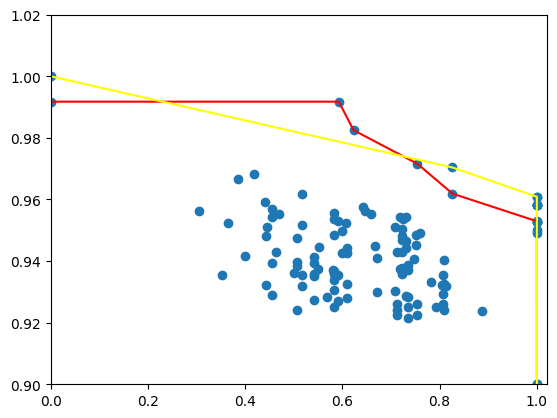

In [87]:
import matplotlib.pyplot as plt 
plt.scatter(pairs[:,0],pairs[:,1])
plt.plot(np.array(sorted_pareto)[:,0],np.array(sorted_pareto)[:,1],color='red')
plt.plot(np.array(intervention_pareto)[:,0],np.array(intervention_pareto)[:,1],color='yellow')

plt.xlim([0,1.02])

plt.ylim([0.9,1.02])

In [38]:
U = set()
for _, elems in final_vals:
    U.update(elems)
U = list(U)  # universe of elements
elem_to_idx = {e:i for i,e in enumerate(U)}

In [34]:
np.mean(np.array(cbm_accuracy_by_concept)[idx])

0.9167986111111112

In [35]:
np.mean(sorted(cbm_accuracy_by_concept)[-20:])

0.9996124999999999

In [16]:
# Find the tradeoff
cbm_accuracy_by_concept

[0.9488054607508533,
 0.9510807736063709,
 0.7952218430034129,
 0.7963594994311718,
 0.8998862343572241,
 0.9032992036405005,
 0.7974971558589306,
 0.7963594994311718,
 0.9124004550625711,
 0.9135381114903299,
 0.8020477815699659,
 0.7986348122866894,
 0.8782707622298066,
 0.8839590443686007,
 0.8077360637087599,
 0.8088737201365188,
 0.9579067121729238,
 0.9579067121729238,
 0.8043230944254836,
 0.7974971558589306,
 0.8998862343572241,
 0.9010238907849829,
 0.8043230944254836,
 0.7963594994311718]

In [ ]:
if is_main and run_intervention:
    greedy_intervention_reward = {}
    for modification in ["binary"]:
        if modification == "binary" and cbm_accuracy_by_concept is not None and intervention_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        else:
            continue 
        _, greedy_idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
        subset_concept = [modified_concept_predictors[i] for i in greedy_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_intervention_greedy".format(environment_string))

        modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        subset_concept = [modified_concept_predictors[i] for i in greedy_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)

        greedy_intervention_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': greedy_idx
        }

    if greedy_intervention_reward != {}:
        results['intervention_comparison']['greedy'] = greedy_intervention_reward
        print(greedy_intervention_reward)

In [ ]:
if is_main and run_intervention:
    lp_intervention_reward = {}
    for modification in ["binary"]:
        if modification == "binary" and cbm_accuracy_by_concept is not None and intervention_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        else:
            continue 
        _, lp_idx = lp_based_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
        subset_concept = [modified_concept_predictors[i] for i in lp_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_intervention_lp".format(environment_string))

        modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        subset_concept = [modified_concept_predictors[i] for i in lp_idx]

        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)

        lp_intervention_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': lp_idx
        }

    if lp_intervention_reward != {}:
        results['intervention_comparison']['lp'] = lp_intervention_reward
        print(lp_intervention_reward)

In [ ]:
if is_main and run_intervention:
    multiple_lp_intervention_reward = {}
    modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
    subset_concept, multiple_idx = multiple_lp_selection(ground_truth_gym_env,modified_concept_predictors,num_concepts_selected,selection_function,q_estimates,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)

    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_intervention_multiple".format(environment_string))
    multiple_lp_intervention_reward = {}
    modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
    subset_concept = [modified_concept_predictors[i] for i in multiple_idx]
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    multiple_lp_intervention_reward['reward'] = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    multiple_lp_intervention_reward['concepts'] = multiple_idx

    if multiple_lp_intervention_reward != {}:
        results['intervention_comparison']['multiple_lp'] = multiple_lp_intervention_reward
        print(multiple_lp_intervention_reward)

In [ ]:
if is_main and run_intervention:
    imperfect_intervention_reward = {}
    for modification in ["binary"]:
        if modification == "binary" and cbm_accuracy_by_concept is not None and intervention_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        else:
            continue 
        subset_concept, imperfect_idx = imperfect_lp_selection(ground_truth_gym_env,modified_concept_predictors,q_estimates,selection_function,target_abstraction,num_concepts_selected,cbm_accuracy_by_concept,concept_source,environment_string,additional_info,direction='max')
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_intervention_imperfect".format(environment_string))
        modified_concept_predictors = [inaccurate_concepts_binary_intervention(func,acc,intervene_acc,intervention_probability,seed+idx) for (func,acc,intervene_acc,idx) in zip(concept_list,cbm_accuracy_by_concept,intervention_accuracy_by_concept,list(range(len(concept_list))))]
        subset_concept = [modified_concept_predictors[i] for i in imperfect_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)

        imperfect_intervention_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': imperfect_idx
        }

    if imperfect_intervention_reward != {}:
        results['intervention_comparison']['imperfect_lp'] = imperfect_intervention_reward
        print(imperfect_intervention_reward)

### Two-Stage Training

In [14]:
run_two_stage = True

In [16]:
if is_main and run_two_stage:
    env, eval_env, additional_info = get_environment(environment_string,concept_list,seed)
    gold_path = "../../results/models/env={}_training={}_seed={}_two_step.zip".format(environment_string,gold_timesteps,seed)
    if os.path.exists(gold_path):
        gold_model = PPO.load(gold_path)
    else:
        gold_model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",custom_name="{}_gold_two_stage".format(environment_string))
        gold_model.save(gold_path)
    

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

approx_kl,█▄▄▃▃▃▂▃▂▂▄▄▄▃▁▄▄▄▂▂▃▂▄▃▂▂▂▂▂▃▃▂▂▃▃▂▃▂▁▁
avg_norm_reward,▁▁▁▁▁▁▁▁▁▂▂▁▂▂▅▂▁▇▂▄▄▅▆▆▆▄▅▅▃▆▆▆▅▅█▄▅▄▅▅
clip_fraction,▄▄▂▁▂▁▃▂▂▃▆▅▅▃█▂▂▃▃▃▃▂▃▂▂▂▁▁▁▁▂▄▄▄▂▂▁▁▂▂
ema_norm_reward,▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▃▄▄▆▆▆▆▆▇▆▇▆▆▆▆▆▆█▆▅▆▆▆▆▆
entropy_loss,▁▃▃▄▅▅▆▅▅▆▆▇▇▇▇▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▆█████
episode_length,▁▁▁▁▁▁▁▁▂▁▁▁▂▁▁▃▁▃▂█▆▃▄▂▄▄▄▄▄▃▄▄▄▄▅▇█▄▄▅
episode_reward,▁▁▁▁▁▁▁▁▁▁▂▁▂▁▁▃▃▆▇▄█▅▆▄▅▄▅▅▄▅▄█▇▆▅▄▄▄▄▅
explained_variance,▃▆▄▂▂▂▂▂▂▂▂▂▂▃▃▂▂▂▂▂▂▂▂▂▂▂▂▃▃▃▆▄▄▁▃▇██▇▇
value_loss,▁▁▂▂▃▄▃▅▄▄▃▅▄▄▄▆▆▆▇▇▆▆▇▇▅▅▅▅▆▆▃▇▇██▇▆▅▅▅
approx_kl,0.0008
avg_norm_reward,251


approx_kl,▇████▁▄▄▃▅▃▃▃▃▃▂▅▂▃▂▁▅▃▁▄▃▃▄▄▁▂▃▅▃▃▇▆▂▂▃
avg_norm_reward,▁▁▁▁▁▁▂▆▅▅▆▆▄▄▆▅▄▄▅▄▄▅▃▅▆█▆▄▄▅▃██▃▂▇█▅▃▆
clip_fraction,▇▃▂▆▄▄▂▄▅▇▇▄▄▂▁█▃▃▁▂▆▃▃▇▅▅▆▆▄▇▄▂▅▄▆▂▆▆▆▃
ema_norm_reward,▁▁▁▁▁▂▅▄▅▆▅▄▅▆▆▇▇▇▇▅▆▆▅▅▅▇▆▆▄▅▆▆▄▅███▅▆▆
entropy_loss,▂▂▃▃▁▃▃▅▄▄▅▄▄▄▄▅▅▅▃▅▂▃▃▅▆██▇▇▇▇▅▅▅▅▅▄▄▃▃
episode_length,▁▁▁▁▁▁▁▂▄▄▆▅▄▄▅▆▂▅█▄▆██▃▆▅█▇▆█▅▄▄▄▅▄▅██▃
episode_reward,▁▁▁▁▂▃▅▇▆▆▅▆▄▄▅▃▆▆████▇█▅▅▅▇▇▆▆▆▅▅▃▄▇▅▇▆
explained_variance,▂▃▅▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂█▂▂▂▂▂▃▂▂▂▁▂▂▂▂▂▂▂▂▄▂▂
value_loss,▃▂▄▃▅▄▄▃▄▅▃▃▃▁▂▄▃▃▆▂▃▆▄▄▄▅▄▄▄▅▅▄▃▂▂▁▄▁▂█
approx_kl,0.00158
avg_norm_reward,461


In [69]:
ground_truth_env, ground_truth_gym_env, additional_info = get_environment(environment_string, None, seed)   

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [17]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    concept_predictor, acc_list = train_concept_predictor(ground_truth_gym_env,gold_model,concept_list,list(range(len(concept_list))),epochs=100)
    results['two_stage'] = {}
    results['two_stage']['accuracy'] = acc_list.tolist()

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated



Episode 10/25, steps: 500, samples collected: 5999
  Estimated memory: 80.7 MB
Episode 20/25, steps: 500, samples collected: 11970
  Estimated memory: 161.1 MB

✅ Collection complete!
X shape: (15019, 2, 84, 84), dtype: uint8, size: 202.1 MB
Y shape: (15019, 4), dtype: float32
Y contains 4 features per sample
X_data shape: (15019, 2, 84, 84), dtype: uint8
Y_data shape: (15019, 12), dtype: float32
📉 Epoch 1/100 | Train Loss 0.3994 | Val Loss 0.3633 | Val F1 0.8302 | Took 1.71s
📉 Epoch 2/100 | Train Loss 0.3342 | Val Loss 0.3268 | Val F1 0.8514 | Took 1.31s
📉 Epoch 3/100 | Train Loss 0.3149 | Val Loss 0.3503 | Val F1 0.8395 | Took 1.34s
📉 Epoch 4/100 | Train Loss 0.3035 | Val Loss 0.3209 | Val F1 0.8554 | Took 1.28s
📉 Epoch 5/100 | Train Loss 0.2932 | Val Loss 0.3137 | Val F1 0.8598 | Took 1.32s
📉 Epoch 6/100 | Train Loss 0.2865 | Val Loss 0.3132 | Val F1 0.8609 | Took 1.35s
📉 Epoch 7/100 | Train Loss 0.2781 | Val Loss 0.3362 | Val F1 0.8504 | Took 1.29s
📉 Epoch 8/100 | Train Loss 0.2712

In [18]:
np.mean(acc_list)

0.8493952507767419

In [19]:
acc_list

array([0.97037284, 0.97170439, 0.81691079, 0.78428762, 0.80659121,
       0.82623169, 0.90446072, 0.92743009, 0.80925433, 0.77363515,
       0.78129161, 0.82057257])

In [18]:
X_data, Y_data = collect_cartpole_data(ground_truth_gym_env,gold_model,concept_list,num_episodes=100)
Y_data = [[c(i) for c in concept_list] for i in Y_data] 
Y_data = np.array(Y_data)


Episode 10/100, steps: 18
Episode 20/100, steps: 26
Episode 30/100, steps: 17
Episode 40/100, steps: 12
Episode 50/100, steps: 21
Episode 60/100, steps: 32
Episode 70/100, steps: 10
Episode 80/100, steps: 12
Episode 90/100, steps: 10
Episode 100/100, steps: 43

Collected 2633 samples
X shape: (2633, 4, 84, 84)
Y shape: (2633, 4)
Velocity range: [-2.943, 2.670]
Samples with velocity < -0.02: 4523 (42.95%)


In [19]:
np.mean(Y_data,axis=0)

array([0.27952905, 0.72047095, 0.50360805, 0.49639195, 0.37903532,
       0.62096468, 0.50968477, 0.49031523, 0.46448918, 0.53551082,
       0.66046335, 0.33953665, 0.50056969, 0.49943031, 0.63995442,
       0.36004558])

In [21]:
preds = torch.round(torch.sigmoid(concept_predictor(torch.Tensor(X_data/255).cuda()))).detach().cpu().numpy()

In [23]:
np.mean(preds == np.array(Y_data),axis=0)

array([-0.00259357, -0.00392939, -0.00869643, -0.00869643, -0.01092473,
       -0.02142791, -0.0636505 , -0.0640303 , -0.0201825 , -0.02247435,
       -0.01411886, -0.01811324, -0.07137748, -0.0698583 , -0.01857292,
       -0.01914914])

In [20]:
two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, concept_list, seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=list(range(len(concept_list))))   

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

In [3]:
concept_predictor.eval()  # Set to eval mode
concept_predictor = torch.jit.script(concept_predictor)  # JIT compile
# OR
concept_predictor = torch.compile(concept_predictor)  # PyTorch 2.0+ compile


NameError: name 'concept_predictor' is not defined

In [21]:
model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=500_000,custom_name="{}_two_stage_greedy".format(environment_string))  

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated

ALSA lib pulse.c:242:(pulse_connect) PulseAudio: Unable to connect: Connection terminated



approx_kl,▅█▅▅▄▅▃▃▂▄▅▃▂▃▁▁▂▃▃▃▃▂▁▁▃▂▃▃▂▂▃▁▅▃▁▂▂▂▂▂
avg_norm_reward,▁▂▂▁▂▄▂▂▃▂▃▇▄▅▆▆▅▄▇▆▄▄▆▃▆▅▆▄█▄▇▄▆█▅▇▇▄▅▄
clip_fraction,█▄▂▁▂▃▂▁▁▂▁▃▁▁▁▂▂▃▃▂▁▂▂▁▂▂▃▃▁▂▁▁▁▂▂▂▂▁▁▂
ema_norm_reward,▁▁▁▂▂▃▃▃▄▆▆▇▆▅▅▆▇▇▇█▇▆▇▆▆█▇▆▇▇▇████▆▇▇▇▇
entropy_loss,▁▁▃▃▄▄▅▅▅▆▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████
episode_length,▁▂▁▂▁▃▄▃▃▃▄▃▄▄▃▄▄▅▆▆▅▄▃▃▄█▇▄▄▃▄▃▄█▆▆▅▃▂▆
episode_reward,▁▁▁▂▁▁▂▂▁▂▃▃▂▃▃▃▃▃▃▃▄▂▅▄▇▃▂▃▃▃▃▄█▃▃▃▅▄▃▃
explained_variance,▁▁▁▁▁▁▃▃▆▃▅▁▁▂▃▄▅▅▂▄▅▄▄▄▅▅▅▅▅▅▆▆▆▅▇▆██▆█
value_loss,▁▁▄▅█▇▆▇▆▆▆▇▇▆█▆▆▇▆▆▇▇▆▆▆▇▆▆▆▇▆▆▇▆▆▇▇▆▆▆
approx_kl,0.00118
avg_norm_reward,198


In [16]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    greedy_two_stage = {}
    greedy_concepts, greedy_idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)
    print("{} concepts".format(len(greedy_concepts)))
    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, greedy_concepts, seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=greedy_idx)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_two_stage_greedy".format(environment_string))    
    greedy_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['greedy'] = {'reward': greedy_two_stage_reward, 'concepts': greedy_idx}
    print(greedy_two_stage_reward)



16 concepts


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  

/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/environment_wrappers.py:161: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  obs_array = torch.Tensor([processed_obs]).cuda()
/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/environment_wrappers.py:161: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  obs_array = torch.Tensor([processed_obs]).cuda()
/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/environment_wrappers.py:161: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider c

approx_kl,▇▄▄▄▄▃▃▃▃▅▇▅▃▂▂▃▆▅▅▁▅▄▃▃▃▄▂▃▅▅▂▅▅▅▅▂▁▃█▃
avg_norm_reward,▁▃▃▃▄▄▂▄▃▃▃▆▂▃▄▄▃█▄▃▆▃▆▄▄▅▅▃▂▃▃▃▃▄▄▅▃▅▅▆
clip_fraction,▁▁▁▁▂▄▃▄▄▄▄▃▁▂▃▃▁█▃▁▁▃▂▁▄▂▂▁▂▂▄▄▂▂▂▁▂▅▂▃
ema_norm_reward,▁▄▅▄▄▅▅▄▆▅▆▅▄▆▆▆▅▄█▆▅▅▄▇█▆▆▆▅▆▆▆▆█▅▆▃▆▅▅
entropy_loss,▂▁▅▅▅▅▅▆▆▆▇▇▇██▆▆▅▆▆▅▅▆▆▆▅▅▄▅▆▆▆▆▇▆▇▇▇▆▆
episode_length,▁▁▃▄▃▅▂▂▄▂▃▂▂▄▅▄▅▃▃▂▃▂█▂▃▃▄▆▂▂▃▃▃▂▄▂▃▃▃▃
episode_reward,▁▃▃▂▄▅▃█▄▂▃▁▃▄▆▃▃▅▃▃▄▄█▂▃▄▆▄▃▂▃▄▃▂▆▄▃▆▂▂
explained_variance,▅▁▂▄▅▇▆▆▇▇▇▇▇▇▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇█▇█▇▇██▇▇▇█
value_loss,▁▂▃▄▅▇▇▇▇▇▆▅▆▆▆▆▆▇▆███▇▇▆▆▇██▇▇▇▅▇▇▇▇█▇▇
approx_kl,0.00356
avg_norm_reward,55


64.88657105606258


In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    multiple_concepts, multiple_idx = multiple_lp_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)

    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, multiple_concepts, seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=multiple_idx)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_two_stage_multiple".format(environment_string))    
    multiple_iterative_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['multiple'] = {'reward': multiple_iterative_two_stage_reward, 'concepts': multiple_idx}
    print(multiple_iterative_two_stage_reward)



In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    lp_concepts, lp_idx = lp_based_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates,concept_source)

    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, lp_concepts, seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=lp_idx)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_two_stage_lp".format(environment_string))    
    lp_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['lp'] = {'reward': lp_two_stage_reward, 'concepts': lp_idx}
    print(lp_two_stage_reward)



In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    acc_list = results['two_stage']['accuracy']
    top_k_idx = np.argsort(acc_list)[-num_concepts_selected:].tolist()
    top_k_concepts = [concept_list[i] for i in top_k_idx]
    
    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, top_k_concepts, seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=top_k_idx)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_two_stage_topk".format(environment_string))    
    top_k_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['top_k'] = {'reward': top_k_two_stage_reward, 'concepts': top_k_idx}
    print(top_k_two_stage_reward)



In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    acc_list = results['two_stage']['accuracy']
    imperfect_concepts, imperfect_idx = imperfect_lp_selection(ground_truth_gym_env,concept_list,q_estimates,selection_function,target_abstraction,num_concepts_selected,acc_list,concept_source,environment_string,additional_info,direction='max')
    
    two_stage_env, two_stage_gym_env, additional_info = get_environment(environment_string, imperfect_concepts, seed,fast_predictor=concept_predictor,use_processed=True,concept_idx=imperfect_idx)   
    model = train_ppo_model(two_stage_env,environment_string,policy="MlpPolicy",total_timesteps=training_timesteps,custom_name="{}_two_stage_imperfect".format(environment_string))    
    imperfect_two_stage_reward = evaluate_model(environment_string,two_stage_gym_env,additional_info,model,seed)

    results['two_stage']['imperfect'] = {'reward': imperfect_two_stage_reward, 'concepts': imperfect_idx}
    print(imperfect_two_stage_reward)

## Ablations

### Reward Perturbation

In [ ]:
if is_main and reward_error > 0:
    results['reward_error'] = {}
    perturbed_groundtruth_eval_env = RewardPerturbationWrapper(ground_truth_gym_env,reward_error)

    if selection_function == "q_value":
        if environment_string == "mimic":
            q_estimates_perturbed = rollout_q_estimates_td(groundtruth_model,GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])),concept_list,learning_rate=1e-3,mimic=True,total_timesteps=5000,final_training=0)
        else:
            q_estimates_perturbed = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)
    elif selection_function == "policy":
        if environment_string == "mimic":
            q_estimates_perturbed = rollout_pi_estimates(groundtruth_model,GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])),concept_list,mimic=True)
        else:
            q_estimates_perturbed = rollout_pi_estimates(groundtruth_model,ground_truth_gym_env,concept_list)

    subset_concept, greedy_perturbed_idx = greedy_selection(concept_list,num_concepts_selected,selection_function,q_estimates_perturbed,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    perturbed_model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    greedy_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,perturbed_model,seed)
    results['reward_error']['greedy'] = {
        'reward': greedy_selection_perturbed_reward,
        'concepts': greedy_perturbed_idx
    }
    print(greedy_selection_perturbed_reward)

In [ ]:
if is_main and reward_error > 0:
    subset_concept, greedy_perturbed_iterative_idx = greedy_iterative_selection(concept_list,num_concepts_selected,selection_function,q_estimates_perturbed,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    greedy_iterative_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['reward_error']['greedy_iterative'] = {
        'reward': greedy_iterative_selection_perturbed_reward,
        'concepts': greedy_perturbed_iterative_idx
    }
    print(greedy_iterative_selection_perturbed_reward)

In [ ]:
if is_main and reward_error > 0:
    subset_concept, lp_perturbed_idx = lp_based_selection(concept_list,num_concepts_selected,selection_function,q_estimates_perturbed,concept_source)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,environment_string,total_timesteps=training_timesteps,policy="MlpPolicy",additional_info=additional_info)
    lp_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['reward_error']['lp'] = {
        'reward': lp_selection_perturbed_reward,
        'concepts': lp_perturbed_idx
    }
    print(lp_selection_perturbed_reward)

### Comparison with Concept Completeness

In [ ]:
# TODO: Create a Shapley-based baseline
if is_main and assess_completeness:
    pass 


## Save Data

In [ ]:
if is_main:
    save_path = get_save_path(out_folder,save_name)

In [ ]:
if is_main:
    delete_duplicate_results(out_folder,"",results)

In [ ]:
if is_main:
    json.dump(results,open('../../results/'+save_path,'w'))

In [ ]:
if is_main:
    ground_truth_env.close()
    ground_truth_gym_env.close()
    env.close()
    eval_env.close()